In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
pd.options.display.max_rows=2000

In [3]:
base_path='../data/clean'

In [4]:
#read cleaned data
products_df=pd.read_csv(f'{base_path}/products_cl.csv')
orders_df=pd.read_csv(f'{base_path}/orders_cl.csv')
brands_df=pd.read_csv(f'{base_path}/brands_cl.csv')
orderlines_df=pd.read_csv(f'{base_path}/orderlines_cl.csv')

In [5]:
orders_df['created_date']=pd.to_datetime(orders_df['created_date'])

In [6]:
orderlines_df['date']=pd.to_datetime(orderlines_df['date'])

### Discounts analysis

In [7]:
# Discount is the diffrence between the unit_price in orderlines and price in products
# we need to merge this two table together

In [8]:
products_df['sku'].nunique()

9992

In [9]:
orderlines_df['sku'].nunique()

5098

In [10]:
orderlines_df

,id,id_order,product_id,product_quantity,sku,unit_price,date
0,1119116,299545,0,1,OWC0100,47.49,2017-01-01 01:46:16
1,1119119,299546,0,1,IOT0014,18.99,2017-01-01 01:50:34
2,1119120,295347,0,1,APP0700,72.19,2017-01-01 01:54:11
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01-01 02:20:14
4,1119145,299561,0,1,PEB0015,142.49,2017-01-01 02:38:50
...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03-14 11:42:41
53227,1649512,527070,0,2,APP0698,9.99,2018-03-14 11:49:01
53228,1649522,527074,0,2,APP0698,9.99,2018-03-14 11:49:36
53229,1649565,527096,0,3,APP0698,9.99,2018-03-14 11:54:35


In [11]:
ol_p_df=orderlines_df.merge(products_df,on='sku',how='left')

In [12]:
ol_p_df.columns

Index(['id', 'id_order', 'product_id', 'product_quantity', 'sku', 'unit_price',
       'date', 'name', 'desc', 'price', 'in_stock', 'type'],
      dtype='object')

In [13]:
ol_p_df.drop(['id','product_id','name','desc','in_stock','type'],axis=1,inplace=True)

In [14]:
ol_p_df.rename(columns={'product_quantity':'qty','id_order':'order_id'},inplace=True)

In [15]:
ol_p_df.rename(columns={'unit_price':'sale_price','price':'base_price'},inplace=True)

In [16]:
ol_p_df=ol_p_df[['date','order_id','sku','qty','base_price','sale_price']]

In [17]:
ol_p_df.loc[:,'discount']=ol_p_df['base_price']-ol_p_df['sale_price']

In [18]:
ol_p_df.loc[:,'discount_rate']=round(ol_p_df['discount']/ol_p_df['base_price'],3)

In [19]:
ol_p_df.loc[:,'date']=ol_p_df['date'].dt.date

In [20]:
ol_p_df.loc[:,'is_discounted']=True
ol_p_df.loc[ol_p_df['sale_price']>=ol_p_df['base_price'],'is_discounted']=False

In [21]:
ol_p_df.loc[:,'total_sale_price']=ol_p_df['sale_price']*ol_p_df['qty']

#### What is the time period that the dataset covers?

In [22]:
min_date=ol_p_df['date'].min().date()
max_date=ol_p_df['date'].max().date()

print(f'The dataset covers from {min_date} to {max_date}')

The dataset covers from 2017-01-01 to 2018-03-14


#### What is the overall revenue for that time?

In [23]:
overall_revenue=float(round((ol_p_df['qty']*ol_p_df['sale_price']).sum(),1))
overall_revenue

7817204.4

#### Do discounted products lead to more sales ?

In [24]:
discounted_p=ol_p_df.groupby('is_discounted').agg(total_unit_sold=('qty','sum')).reset_index()
discounted_p['is_discounted'] = discounted_p['is_discounted'].map({
    True: 'Discounted',
    False: 'Not-discounted'
})
total_units=discounted_p['total_unit_sold'].sum()
discounted_p['percentage'] = (discounted_p['total_unit_sold'] /total_units  * 100).round(1)

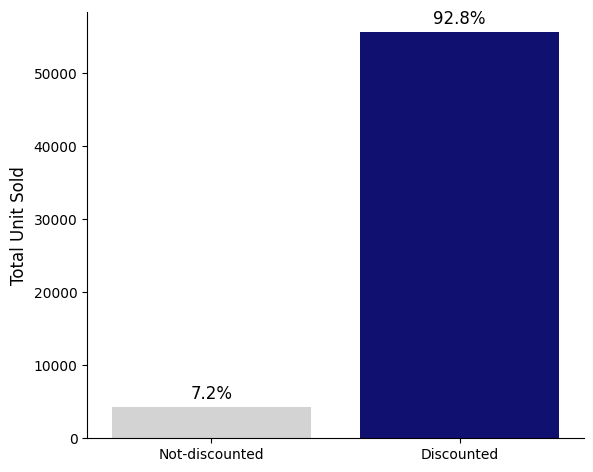

In [25]:
g=sns.catplot(
    data=discounted_p,
    x='is_discounted',
    y='total_unit_sold',
    kind='bar',
    height=5,
    aspect=1.2,
    palette= ['lightgray', 'navy'],
    hue='is_discounted'
)
ax = g.ax
for i, row in discounted_p.iterrows():
    ax.text(
        i,                                  
        row['total_unit_sold'] + 0.01 * total_units,  
        f"{row['percentage']}%",            
        ha='center', va='bottom', fontsize=12
    )
ax.set_title('')
g.set_axis_labels("", "Total Unit Sold", fontsize=12)

#### Do discounted products generate more or less total revenue?

In [26]:
discounted_r=ol_p_df.groupby('is_discounted').agg(total_revenue=('total_sale_price','sum')).reset_index()

In [27]:
discounted_r['is_discounted'] = discounted_r['is_discounted'].map({
    True: 'Discounted',
    False: 'Not-discounted'
})
total_revenue=discounted_r['total_revenue'].sum()
discounted_r['percentage'] = (discounted_r['total_revenue'] /total_revenue  * 100).round(1)

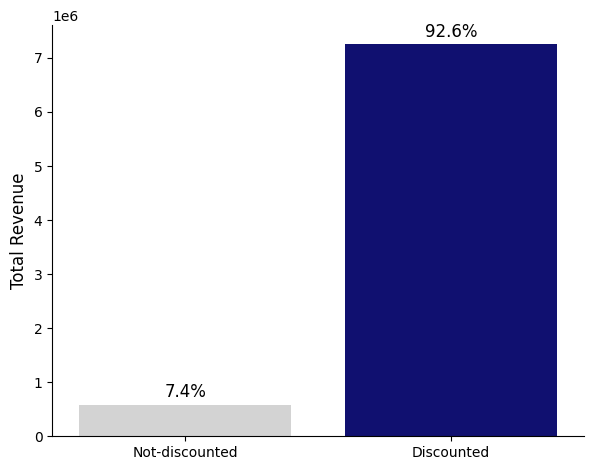

In [28]:
g=sns.catplot(
    data=discounted_r,
    x='is_discounted',
    y='total_revenue',
    kind='bar',
    height=5,
    aspect=1.2,
    palette= ['lightgray', 'navy'],
    hue='is_discounted'
)
ax = g.ax
for i, row in discounted_r.iterrows():
    ax.text(
        i,                                  
        row['total_revenue'] + 0.01 * total_revenue,  
        f"{row['percentage']}%",            
        ha='center', va='bottom', fontsize=12
    )
ax.set_title('')
g.set_axis_labels("", "Total Revenue", fontsize=12)

#### How big are the offered discounts as a percentage of the product prices?


In [29]:
float(round(ol_p_df['discount_rate'].mean(),2))

0.21

#### What are the most sold products? are they discounted or not? how is the discount rate of them?


In [30]:
ol_p_df.groupby(['sku','is_discounted']).agg(total_unit_sold=('qty','count'),avg_discount_rate=('discount_rate','mean')).nlargest(10,'total_unit_sold')

,,total_unit_sold,avg_discount_rate
sku,is_discounted,,
APP1190,True,860,0.224103
APP0698,True,478,0.599979
APP1922,True,449,0.113960
APP0927,True,378,0.509794
SAM0074,True,298,0.152453
WDT0183,True,289,0.183606
CRU0051,True,269,0.144814
APP2446,True,260,0.137908
APP1970,True,220,0.135859


#### What are the products that generate the most revenue? Are they discounted or not?

In [54]:
ol_p_df.groupby(['sku','is_discounted']).agg(total_revenue=('total_sale_price','sum'),avg_discount_rate=('discount_rate','mean')).nlargest(10,'total_revenue')

,,total_revenue,avg_discount_rate
sku,is_discounted,,
LGE0044,True,133575.86,0.053793
APP2446,True,104560.64,0.137908
APP2477,True,85301.93,0.023520
APP1970,True,80715.76,0.135859
APP1922,True,75196.26,0.113960
APP2072,True,74964.06,0.119303
APP2485,True,70721.79,0.026103
WDT0183,True,65589.96,0.183606
APP2483,True,60090.08,0.025226


#### Are there seasonal patterns in the evolution of sales?

In [31]:
ol_p_df.loc[:,'year']=ol_p_df['date'].dt.year
ol_p_df.loc[:,'month']=ol_p_df['date'].dt.month
ol_p_df.loc[:,'weekday']=ol_p_df['date'].dt.weekday

In [41]:
month_by_sale=ol_p_df.resample('ME',on='date').agg(count_sold_products=('qty','sum'),total_revenue=('total_sale_price','sum'))

In [42]:
month_by_sale

,count_sold_products,total_revenue
date,,
2017-01-31,6855,609260.70
2017-02-28,2918,327483.46
2017-03-31,246,25508.97
2017-04-30,2132,230379.32
2017-05-31,2573,331725.55
2017-06-30,2051,285107.03
2017-07-31,4625,603124.23
2017-08-31,3023,376329.62
2017-09-30,2788,393137.39


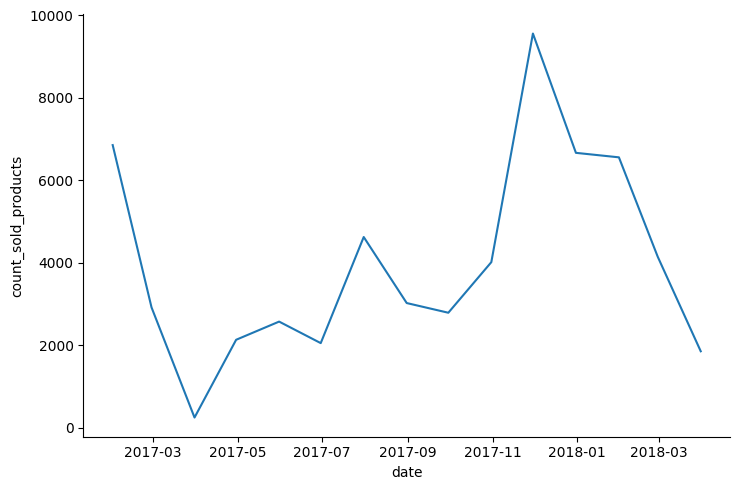

In [49]:
sns.relplot(
    kind='line',
    data=month_by_sale,
    x='date',
    y='count_sold_products',
    height=5,
    aspect=1.5,
)

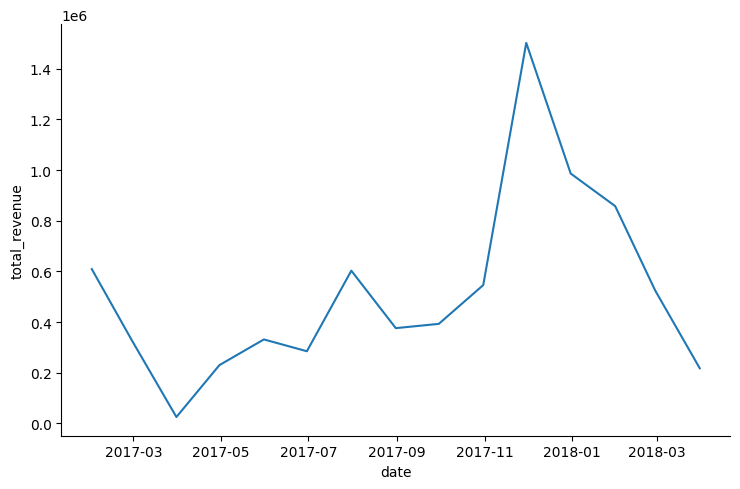

In [44]:
sns.relplot(
    kind='line',
    data=month_by_sale,
    x='date',
    y='total_revenue',
    height=5,
    aspect=1.5,
)

#### How should products be classified into different categories to simplify reports and analysis?


In [64]:
products_df.type.value_counts().nlargest(50).sum()/products_df.shape[0]

np.float64(0.8909127301841473)

In [68]:
products_df[products_df['type']=='11865403']

,sku,name,desc,price,in_stock,type
18,MUV0009,Muvit Back Clear Case iPhone 4 / 4S Transparent,Case iPhone 4 / 4S polycarbonate.,9.99,0,11865403
37,MUV0023,Extreme Muvit iPhone and iPod BikeMount sleeve...,IPhone and iPod support sleeve waterproof App ...,35.90,0,11865403
132,ROL0010,Rollei Chest Mount iPhone 4 / 4S,Case iPhone 4 / 4S for sport.,49.99,0,11865403
194,KEN0059,Kensington Soft Case cover iPhone 5 / 5S black,Soft Case iPhone 5 / 5S.,14.99,0,11865403
195,KEN0062,Kensington Thin Back Case iPhone 5 / 5S Gray,Back Case iPhone 5 / 5S.,19.99,0,11865403
196,KEN0063,Kensington Thin Back Case iPhone 5 / 5S Pink,Back Case iPhone 5 / 5S.,19.99,0,11865403
197,MUV0042,Clear Back Case Muvit iPhone / 5s / 5 transparent,iPhone back cover tranparente SE / 5s / 5.,9.99,0,11865403
199,MUV0047,Muvit MiniGel Funda iPhone 5 / 5S White,Rubber cover iPhone 5 / 5S.,8.99,0,11865403
200,MUV0053,Muvit Slim case iPhone 5 / 5S purple,Imiatación Leather Case Cover for iPhone 5 / 5S.,14.99,0,11865403
203,CYG0042,Cygnett UrbanShield Hard Case for iPhone 5 / 5...,Hard Case + Silver Storm screensaver iPhone 5 ...,19.99,1,11865403


In [ ]:
def create_category(type:str,column:list[str]):
    for desc in column:
        


#### What is the distribution of product prices across different categories?
